# ДЗ-1 — Analytical performance model небольшой CNN

Цель: вывести явные функции `FLOPs(S,B)`, `Memory(S,B)`, `Latency(S,B,θ)` и `Energy(S,B,θ_energy)`, измерить **132** конфигурации на одной GPU и проверить предсказания на ранее не использованных парах `(S,B)`.

**Порядок:** загрузить **этот один файл** `hw1.ipynb` в Colab с GPU T4 и выполнить сверху вниз. Код модели, equations и measurement встроен в ноутбук; локальные `.py` нужны для репозитория и тестов. Полный grid может идти долго и содержать `OOM` — это часть эксперимента. CSV записывается после каждой конфигурации, поэтому запуск можно возобновить. Числа и графики появляются только после реального измерения.

In [15]:
from pathlib import Path
import sys, json, platform, importlib.util, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

for package, module in [('nvidia-ml-py', 'pynvml'), ('scipy', 'scipy')]:
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

if not torch.cuda.is_available():
    raise RuntimeError('Включите GPU runtime в Colab: Runtime → Change runtime type → T4 GPU')
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False
GPU_NAME = torch.cuda.get_device_name(0)
if 'T4' not in GPU_NAME:
    raise RuntimeError(f'Для этой серии выбран T4; текущая GPU: {GPU_NAME}')
ROOT = Path.cwd().resolve()
RESULTS = ROOT / 'hw1' / 'results' if (ROOT / 'hw1').is_dir() else ROOT / 'hw1_results'
(RESULTS / 'figures').mkdir(parents=True, exist_ok=True)
print('Python:', platform.python_version(), 'PyTorch:', torch.__version__)
print('CUDA:', torch.version.cuda, '| GPU:', GPU_NAME)
print('Results:', RESULTS)


Python: 3.13.15 PyTorch: 2.11.0+cu128
CUDA: 12.8 | GPU: Tesla T4
Results: /content/hw1/results


## Встроенный код: model, equations, measurement, calibration

Эти ячейки повторяют соответствующие `.py` файлы репозитория, чтобы Colab не зависел от локального файлового дерева.

In [16]:
"""The exact FP32 inference network used throughout Homework 1."""
from torch import nn


class SmallCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        layers = []
        convs = (
            (3, 32, 7, 2),
            (32, 64, 5, 1),
            (64, 128, 3, 2),
            (128, 256, 1, 1),
            (256, 256, 3, 2),
            (256, 512, 1, 1),
        )
        for index, (in_channels, out_channels, kernel, stride) in enumerate(convs):
            layers += [
                nn.Conv2d(in_channels, out_channels, kernel, stride,
                          padding=kernel // 2, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ]
            if index == 0:
                layers.append(nn.MaxPool2d(3, stride=2, padding=1))
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 100),
        )

    def forward(self, x):
        return self.head(self.features(x))


In [17]:
"""Explicit analytic equations. S and B are NumPy-broadcastable scalars/arrays.

Assumptions: NCHW FP32, eval+inference_mode, Conv-BN-ReLU after each conv,
no residuals, inplace ReLU. Arithmetic counts floating add/multiply/divide;
comparisons (ReLU/MaxPool) are not FLOPs. Memory is a lower-bound live-tensor
estimate; cuDNN workspaces, allocator rounding and CUDA context are excluded.
"""
import numpy as np

# input channels, output channels, kernel, output resolution divisor
CONVS = ((3, 32, 7, 2), (32, 64, 5, 4), (64, 128, 3, 8),
         (128, 256, 1, 8), (256, 256, 3, 16), (256, 512, 1, 16))


def _sb(image_size, batch):
    s, b = np.broadcast_arrays(np.asarray(image_size, dtype=float),
                               np.asarray(batch, dtype=float))
    if np.any(s <= 0) or np.any(b <= 0):
        raise ValueError("S and B must be positive")
    return s, b


def model_bytes():
    """FP32 parameters and BN buffers, including six int64 batch counters."""
    conv_params = sum(ci * co * k * k for ci, co, k, _ in CONVS)
    bn_floats = sum(4 * co for _, co, _, _ in CONVS)
    linear_params = 512 * 256 + 256 + 256 * 100 + 100
    return 4 * (conv_params + bn_floats + linear_params) + 8 * len(CONVS)


def flops(image_size, batch):
    """Forward FLOPs: 2 per MAC, 2 per BN output, 1 per GAP input, biases."""
    s, b = _sb(image_size, batch)
    total = 0.0
    for ci, co, k, divisor in CONVS:
        pixels = (s / divisor) ** 2
        total += b * co * pixels * (2 * ci * k * k + 2)
    total += b * 512 * (s / 16) ** 2  # GAP: (n-1) adds + division
    total += b * (2 * 512 * 256 + 256 + 2 * 256 * 100 + 100)
    return total


def memory(image_size, batch):
    """Predicted peak bytes: weights + persistent input + two conv1 activations.

The input x remains referenced by the caller. BN1 holds both conv1 output
and BN output; both contain B*32*(S/2)^2 float32 values. This is the
largest live pair in this sequential network. It omits temporary workspaces.
"""
    s, b = _sb(image_size, batch)
    return model_bytes() + 4 * b * (3 * s**2 + 2 * 32 * (s / 2)**2)


def bytes_moved(image_size, batch):
    """Approximate global-memory traffic: each op reads inputs and writes outputs.

Cache reuse, temporary workspaces, kernel fusion and allocator traffic are
excluded. Conv weights are counted once per forward, not once per pixel.
"""
    s, b = _sb(image_size, batch)
    total_elements = 0.0
    previous = 3 * b * s**2
    for index, (ci, co, k, divisor) in enumerate(CONVS):
        output = b * co * (s / divisor)**2
        total_elements += previous + ci * co * k * k + output  # conv
        total_elements += 2 * output + 4 * co  # BN read/write + vectors
        total_elements += 2 * output  # inplace ReLU read/write
        previous = output
        if index == 0:
            pooled = b * co * (s / 4)**2
            total_elements += previous + pooled
            previous = pooled
    total_elements += previous + b * 512  # GAP
    total_elements += b * 512 + 512 * 256 + b * 256  # linear1
    total_elements += 2 * b * 256  # inplace ReLU
    total_elements += b * 256 + 256 * 100 + b * 100  # linear2
    return 4 * total_elements


def latency(image_size, batch, theta):
    """Roofline-style seconds: launch overhead + max(compute, memory time)."""
    return (theta["launch_seconds"] + np.maximum(
        flops(image_size, batch) / theta["compute_flops_per_s"],
        bytes_moved(image_size, batch) / theta["memory_bytes_per_s"]))


def energy(image_size, batch, theta_energy):
    """Whole-GPU joules: idle baseline over predicted time + dynamic terms."""
    return (theta_energy["idle_watts"] *
            latency(image_size, batch, theta_energy["latency"]) +
            theta_energy["fixed_joules"] +
            theta_energy["joules_per_gflop"] * flops(image_size, batch) / 1e9 +
            theta_energy["joules_per_gbyte"] * bytes_moved(image_size, batch) / 1e9)


In [18]:
"""GPU measurements for the 132-point grid; safe to resume after OOM/interruption."""
import gc
import math
import threading
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch


ACCELERATOR_ERROR = getattr(torch, "AcceleratorError", torch.cuda.OutOfMemoryError)

BASE_S = (32, 64, 128, 224, 256, 384, 512)
BASE_B = (1, 2, 4, 8, 16, 32, 64, 128, 256)


def build_grid(seed=2026):
    rng = np.random.default_rng(seed)
    extra_s = rng.choice([v for v in range(32, 513, 16) if v not in BASE_S],
                         size=4, replace=False)
    extra_b = rng.choice([v for v in range(1, 257) if v not in BASE_B],
                         size=3, replace=False)
    points = [(int(s), int(b)) for s in sorted((*BASE_S, *extra_s))
              for b in sorted((*BASE_B, *extra_b))]
    flags = np.zeros(len(points), dtype=bool)
    flags[rng.choice(len(points), size=round(0.2 * len(points)), replace=False)] = True
    return pd.DataFrame({"S": [p[0] for p in points],
                         "B": [p[1] for p in points],
                         "is_validation": flags})


def _synchronize():
    torch.cuda.synchronize()


def _one_forward(model, x):
    with torch.inference_mode():
        return model(x)


def _power_series(handle, stop, samples):
    import pynvml
    while not stop.is_set():
        try:
            samples.append((time.perf_counter(),
                            pynvml.nvmlDeviceGetPowerUsage(handle) / 1000.0))
        except pynvml.NVMLError:
            break
        stop.wait(0.02)


def _energy_per_forward(model, x, repetitions, handle):
    if handle is None:
        return float("nan")
    samples = []
    stop = threading.Event()
    sampler = threading.Thread(target=_power_series, args=(handle, stop, samples),
                               daemon=True)
    _synchronize()
    sampler.start()
    start = time.perf_counter()
    for _ in range(repetitions):
        _one_forward(model, x)
    _synchronize()
    elapsed = time.perf_counter() - start
    stop.set()
    sampler.join()
    if len(samples) < 2:
        return float("nan")
    # Sensor samples cover the whole-GPU power during repeated forwards.
    return float(np.mean([watts for _, watts in samples]) * elapsed / repetitions)


def measure_one(model, image_size, batch, handle=None, latency_repeats=7):
    """Median synchronized wall time, peak PyTorch allocated bytes, GPU joules.

    Input allocation is included in peak, as the input stays alive throughout
    forward. The returned output is released before the memory reading.
    """
    x = torch.randn(batch, 3, image_size, image_size, device="cuda", dtype=torch.float32)
    try:
        for _ in range(3):
            _one_forward(model, x)
        _synchronize()
        torch.cuda.reset_peak_memory_stats()
        times = []
        for _ in range(latency_repeats):
            _synchronize()
            start = time.perf_counter()
            _one_forward(model, x)
            _synchronize()
            times.append(time.perf_counter() - start)
        peak = torch.cuda.max_memory_allocated()
        median = float(np.median(times))
        energy_repeats = max(5, min(1000, math.ceil(0.5 / median)))
        joules = _energy_per_forward(model, x, energy_repeats, handle)
        # Profiler reports estimated conv/linear FLOPs, not a hardware counter.
        with torch.profiler.profile(
            activities=[torch.profiler.ProfilerActivity.CPU],
            with_flops=True, record_shapes=True,
        ) as prof:
            _one_forward(model, x)
            _synchronize()
        prof_flops = sum(event.flops for event in prof.key_averages())
        return {"status": "ok", "latency_s": median,
                "memory_bytes": int(peak), "energy_j": joules,
                "flops_profiler": int(prof_flops),
                "energy_repeats": energy_repeats}
    finally:
        del x


def init_nvml():
    try:
        import pynvml
        pynvml.nvmlInit()
        return pynvml.nvmlDeviceGetHandleByIndex(torch.cuda.current_device())
    except Exception as exc:
        print(f"NVML unavailable: {exc}; energy_j will be NaN")
        return None


def idle_power_watts(handle, samples=20):
    if handle is None:
        return float("nan")
    import pynvml
    _synchronize()
    values = []
    for _ in range(samples):
        values.append(pynvml.nvmlDeviceGetPowerUsage(handle) / 1000.0)
        time.sleep(0.025)
    return float(np.median(values))


def measure_grid(path, seed=2026, resume=True):
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA GPU is required for real measurements")
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.allow_tf32 = False
    torch.backends.cuda.matmul.allow_tf32 = False
    device_name = torch.cuda.get_device_name(0)
    model = SmallCNN().cuda().eval()
    handle = init_nvml()
    idle = idle_power_watts(handle)
    grid = build_grid(seed)
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    rows = []
    done = set()
    if resume and path.exists() and path.stat().st_size:
        rows = pd.read_csv(path).to_dict("records")
        prior_devices = {str(r.get("gpu_name")) for r in rows}
        if prior_devices != {device_name}:
            raise ValueError(f"Existing CSV is from {prior_devices}; current GPU is {device_name}")
        done = {(int(r["S"]), int(r["B"])) for r in rows}
    for index, row in grid.iterrows():
        s, b = int(row.S), int(row.B)
        if (s, b) in done:
            continue
        record = {"S": s, "B": b, "is_validation": bool(row.is_validation),
                  "gpu_name": device_name, "idle_watts": idle}
        was_oom = False
        try:
            record.update(measure_one(model, s, b, handle))
        except (torch.cuda.OutOfMemoryError, ACCELERATOR_ERROR) as exc:
            if "out of memory" not in str(exc).lower():
                raise
            record.update(status="OOM", latency_s=float("nan"),
                          memory_bytes=float("nan"), energy_j=float("nan"),
                          flops_profiler=float("nan"), energy_repeats=0)
            was_oom = True
        if was_oom:
            gc.collect()
            torch.cuda.empty_cache()
        rows.append(record)
        pd.DataFrame(rows).to_csv(path, index=False)
        if (index + 1) % 10 == 0 or record["status"] == "OOM":
            print(f"{index+1}/{len(grid)}: S={s}, B={b}, {record['status']}")
    return pd.DataFrame(rows).sort_values(["S", "B"]).reset_index(drop=True)


In [19]:
"""Fit latency and whole-GPU energy parameters on train configurations only."""
import numpy as np
from scipy.optimize import least_squares, nnls



def _training(df, column):
    train = df[(df["status"] == "ok") & (~df["is_validation"])].copy()
    train = train[np.isfinite(train[column])]
    if len(train) < 6:
        raise ValueError(f"Need at least 6 finite train measurements for {column}")
    return train


def fit_latency(df):
    train = _training(df, "latency_s")
    f = np.asarray(flops(train.S.to_numpy(), train.B.to_numpy()) / 1e9)
    m = np.asarray(bytes_moved(train.S.to_numpy(), train.B.to_numpy()) / 1e9)
    observed = train.latency_s.to_numpy(dtype=float)
    scale = np.maximum(observed, np.median(observed) * 0.05)

    def residual(p):
        return (p[0] + np.maximum(p[1] * f, p[2] * m) - observed) / scale

    # max() changes branch at memory/compute boundaries; try several starts.
    base_a = max(np.median(observed / np.maximum(f, 1e-12)), 1e-8)
    base_c = max(np.median(observed / np.maximum(m, 1e-12)), 1e-8)
    fits = []
    for af in (0.1, 1.0, 10.0):
        for cf in (0.1, 1.0, 10.0):
            fit = least_squares(residual,
                                [max(np.min(observed) * 0.5, 1e-6),
                                 base_a * af, base_c * cf],
                                bounds=(0, np.inf), x_scale="jac", max_nfev=5000)
            if fit.success:
                fits.append(fit)
    if not fits:
        raise RuntimeError("Latency fit failed for all initializations")
    fit = min(fits, key=lambda candidate: np.sum(candidate.fun**2))
    t0, seconds_per_gflop, seconds_per_gbyte = fit.x
    return {"launch_seconds": float(t0),
            "compute_flops_per_s": float(1e9 / max(seconds_per_gflop, 1e-15)),
            "memory_bytes_per_s": float(1e9 / max(seconds_per_gbyte, 1e-15))}


def fit_energy(df, theta_latency):
    train = _training(df, "energy_j")
    idle = float(np.median(train.idle_watts.to_numpy(dtype=float)))
    if not np.isfinite(idle):
        raise ValueError("NVML idle power is unavailable; cannot fit energy")
    s, b = train.S.to_numpy(), train.B.to_numpy()
    x = np.column_stack((np.ones(len(train)), flops(s, b) / 1e9,
                         bytes_moved(s, b) / 1e9))
    target = train.energy_j.to_numpy(dtype=float) - idle * latency(s, b, theta_latency)
    # Weight by observed energy so large, slow configurations do not erase
    # relative accuracy on short forwards. The floor is train-only.
    scale = np.maximum(train.energy_j.to_numpy(dtype=float),
                       np.quantile(train.energy_j, 0.05))
    (fixed, per_gflop, per_gbyte), _ = nnls(x / scale[:, None], target / scale)
    return {"latency": theta_latency, "idle_watts": idle,
            "fixed_joules": float(fixed),
            "joules_per_gflop": float(per_gflop),
            "joules_per_gbyte": float(per_gbyte)}


def error_summary(measured, predicted):
    measured = np.asarray(measured, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    valid = np.isfinite(measured) & np.isfinite(predicted) & (measured > 0)
    if not np.any(valid):
        return {"n": 0, "median_ape_percent": None, "mean_ape_percent": None}
    ape = 100 * np.abs(predicted[valid] - measured[valid]) / measured[valid]
    return {"n": int(valid.sum()), "median_ape_percent": float(np.median(ape)),
            "mean_ape_percent": float(np.mean(ape))}


## 1. Модель и соглашения

Вход: `B × 3 × S × S`, где `S` кратен 16. Шесть блоков `Conv → BatchNorm → ReLU(inplace)`, после первого блока `MaxPool`. Затем `GlobalAvgPool → Linear(512,256) → ReLU(inplace) → Linear(256,100)`. Каждая `Conv` имеет `bias=False`, `padding=k//2`; сеть работает в `eval()`, FP32 и `torch.inference_mode()`.

| i | Conv | Выходные каналы | Spatial size |
|---|---|---:|---:|
| 1 | 7×7, stride 2, 3→32 | 32 | S/2, после MaxPool — S/4 |
| 2 | 5×5, 32→64 | 64 | S/4 |
| 3 | 3×3, stride 2, 64→128 | 128 | S/8 |
| 4 | 1×1, 128→256 | 256 | S/8 |
| 5 | 3×3, stride 2, 256→256 | 256 | S/16 |
| 6 | 1×1, 256→512 | 512 | S/16 |

In [6]:
model_cpu = SmallCNN().eval()
with torch.inference_mode():
    assert model_cpu(torch.randn(2, 3, 32, 32)).shape == (2, 100)
print(model_cpu)
print(f'Параметры + buffers: {model_bytes()/2**20:.3f} MiB')

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1,

## 2. Вывод аналитических уравнений

Обозначим для каждой свёртки `(c_in,i, c_out,i, k_i, r_i)`, где `r_i` — spatial size из таблицы. `W` — байты параметров и buffers сети; `Q(S,B)` — модельный объём передачи данных из `bytes_moved()`.

**FLOPs:** один MAC = 2 FLOPs. `BatchNorm` в `eval()` считаем как scale + shift (2 FLOPs на output), `GlobalAvgPool` — `(n−1)` сложений + 1 деление (всего `n`), для Linear добавляем bias. ReLU и MaxPool используют сравнения и в floating-point operations не входят:

\[
F(S,B)=B\sum_{i=1}^{6}c_{out,i}r_i^2(2c_{in,i}k_i^2+2)
 +512B(S/16)^2+B(2\cdot512\cdot256+256+2\cdot256\cdot100+100).
\]

**Peak memory:** метрика — `torch.cuda.max_memory_allocated()` за один forward. В базовой аналитической модели вход остаётся живым у вызывающей ячейки; на `BatchNorm` первого блока одновременно живы output Conv1 и output BN1. Это самая большая пара activations:

\[
M(S,B)=W+4B[3S^2+2\cdot32(S/2)^2]\quad\text{bytes}.
\]

В `W` включены FP32 parameters и BatchNorm buffers, включая счётчики `num_batches_tracked`. Уравнение **не** включает cuDNN workspace, allocator rounding, CUDA context и кэши: это осмысленная проверяемая гипотеза, а не обещание точного пика. `OOM` сравниваем с предсказанием и ёмкостью GPU.

**Bytes moved:** для каждой Conv учитываем один read input, один read weights и один write output; для BN/ReLU — read+write; для MaxPool/GAP/Linear аналогично. Игнорируем cache reuse, fusion и cuDNN workspace. Подробная сумма находится в `equations.py`; она не подгоняется по GPU.

**Latency** (seconds):
\[
T(S,B;\theta)=t_0+\max(F(S,B)/P,\ Q(S,B)/R),\quad \theta=(t_0,P,R).
\]
`launch-bound`, `memory-bound`, `compute-bound` — соответственно преобладание `t0`, `Q/R`, `F/P`. Это простая roofline-style модель; перекрытие и kernel selection могут её нарушать.

**Energy** (joules, вся GPU):
\[
E(S,B;\theta_E)=P_{idle}T(S,B;\theta)+e_0+e_FF(S,B)/10^9+e_QQ(S,B)/10^9.
\]
`P_idle` измеряем через NVML, остальные коэффициенты неотрицательно подгоняем только по train points. Во время измерений мощность включает и idle часть GPU.

In [7]:
S_demo = np.array([32, 128, 512])[:, None]
B_demo = np.array([1, 16, 256])[None, :]
print('FLOPs, broadcast shape:', flops(S_demo, B_demo).shape)
print('Memory [GiB]:\n', np.round(memory(S_demo, B_demo) / 2**30, 3))
print('Bytes moved [GB]:\n', np.round(bytes_moved(S_demo, B_demo) / 1e9, 3))

FLOPs, broadcast shape: (3, 3)
Memory [GiB]:
 [[4.000e-03 5.000e-03 2.200e-02]
 [5.000e-03 2.200e-02 3.010e-01]
 [2.200e-02 3.010e-01 4.754e+00]]
Bytes moved [GB]:
 [[5.0000e-03 1.3000e-02 1.4600e-01]
 [1.3000e-02 1.4400e-01 2.2380e+00]
 [1.4400e-01 2.2360e+00 3.5708e+01]]


## 3. Measurement grid и holdout

Семь заданных `S` + четыре случайных кратных 16; девять заданных `B` + три случайных неповторяющихся целых дают 132 пары. Фиксированный seed заранее выбирает 20% пар в `validation`; эти измерения не используются для calibration. Все inputs — случайные тензоры.

In [8]:
grid = build_grid(seed=2026)
assert len(grid) == 132 and not grid.duplicated(['S', 'B']).any()
print('S:', sorted(grid.S.unique()))
print('B:', sorted(grid.B.unique()))
print('train:', (~grid.is_validation).sum(), 'validation:', grid.is_validation.sum())
display(grid.head(12))

S: [np.int64(32), np.int64(48), np.int64(64), np.int64(112), np.int64(128), np.int64(224), np.int64(256), np.int64(352), np.int64(384), np.int64(400), np.int64(512)]
B: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(95), np.int64(98), np.int64(128), np.int64(167), np.int64(256)]
train: 106 validation: 26


,S,B,is_validation
0,32,1,False
1,32,2,False
2,32,4,False
3,32,8,False
4,32,16,False
5,32,32,False
6,32,64,False
7,32,95,False
8,32,98,False
9,32,128,False


## 4. Реальные GPU measurements

Протокол фиксируется в `measure.py`: `cudnn.benchmark=False`, оба `allow_tf32=False`, `eval()`, FP32 и `inference_mode()`. Для каждой пары: warmup, медиана из семи synchronized wall-clock forwards, `max_memory_allocated`, оценка FLOPs через PyTorch profiler и NVML power за серию повторов для энергии одного forward. Profiler даёт **оценку FLOPs операторов Conv/Linear**, а не счётчик инструкций GPU; его расхождение с аналитическим `F` включает BN/GAP.

При `torch.cuda.OutOfMemoryError` строка получает `status=OOM`; CSV сохраняется после каждой точки. NVML должен быть доступен для калибровки энергии. В Colab при необходимости выполните `%pip install nvidia-ml-py scipy pandas matplotlib` и перезапустите kernel.

In [9]:
if not torch.cuda.is_available():
    raise RuntimeError('Для полного grid нужна CUDA GPU')
measurements_path = RESULTS / 'measurements.csv'
df = measure_grid(measurements_path, seed=2026, resume=True)
print(df.status.value_counts())
print('NVML energy points:', np.isfinite(df.energy_j).sum())
display(df.head())

/usr/local/lib/python3.13/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


10/132: S=32, B=128, ok
20/132: S=48, B=95, ok
30/132: S=64, B=32, ok
40/132: S=112, B=8, ok
50/132: S=128, B=2, ok
60/132: S=128, B=256, ok
70/132: S=224, B=128, ok
80/132: S=256, B=95, ok
90/132: S=352, B=32, ok
100/132: S=384, B=8, ok
110/132: S=400, B=2, ok
120/132: S=400, B=256, ok
130/132: S=512, B=128, ok
status
ok    132
Name: count, dtype: int64
NVML energy points: 132


,S,B,is_validation,gpu_name,idle_watts,status,latency_s,memory_bytes,energy_j,flops_profiler,energy_repeats
0,32,1,False,Tesla T4,26.95,ok,0.000876,18789376,0.024619,18450432,572
1,32,2,False,Tesla T4,26.95,ok,0.000968,18899968,0.032577,36900864,517
2,32,4,False,Tesla T4,26.95,ok,0.000999,19121152,0.030866,73801728,501
3,32,8,False,Tesla T4,26.95,ok,0.000970,19563520,0.038773,147603456,516
4,32,16,False,Tesla T4,26.95,ok,0.000892,15000576,0.038977,295206912,561


## 5. Calibration без leakage

Подгоняем `θ` только на `status=ok` и `is_validation=False`. Для latency используем nonnegative least squares на кусочной roofline-функции с несколькими начальными точками. Для energy — неотрицательные коэффициенты, `P_idle` измерен отдельно. `validation` остаётся невидимой для fit.

In [10]:
assert len(df) == 132, 'Grid ещё не завершён; повторно запустите ячейку измерения'
theta_t = fit_latency(df)
theta_e = fit_energy(df, theta_t)
theta = {
    'latency': theta_t,
    'energy': theta_e,
    'software': {'python': platform.python_version(), 'torch': torch.__version__,
                 'cuda': torch.version.cuda},
    'gpu_name': torch.cuda.get_device_name(0),
    'grid_seed': 2026,
}
(RESULTS / 'theta.json').write_text(json.dumps(theta, ensure_ascii=False, indent=2))
print(json.dumps(theta, ensure_ascii=False, indent=2))

{
  "latency": {
    "launch_seconds": 0.000642818669137883,
    "compute_flops_per_s": 2998016379344.5254,
    "memory_bytes_per_s": 95519648576.12013
  },
  "energy": {
    "latency": {
      "launch_seconds": 0.000642818669137883,
      "compute_flops_per_s": 2998016379344.5254,
      "memory_bytes_per_s": 95519648576.12013
    },
    "idle_watts": 26.95,
    "fixed_joules": 0.01777189026667646,
    "joules_per_gflop": 0.015971517916317124,
    "joules_per_gbyte": 0.0
  },
  "software": {
    "python": "3.13.15",
    "torch": "2.11.0+cu128",
    "cuda": "12.8"
  },
  "gpu_name": "Tesla T4",
  "grid_seed": 2026
}


## 6. Validation: measured points и predicted curves

Графики строятся без подгонки на `validation`. Оси имеют единицы; линии — аналитическое предсказание, маркеры — реальные значения (`○ train`, `◆ validation`). Для памяти `× OOM` ставится на уровне VRAM capacity. Графики сохраняются в `results/figures/`.

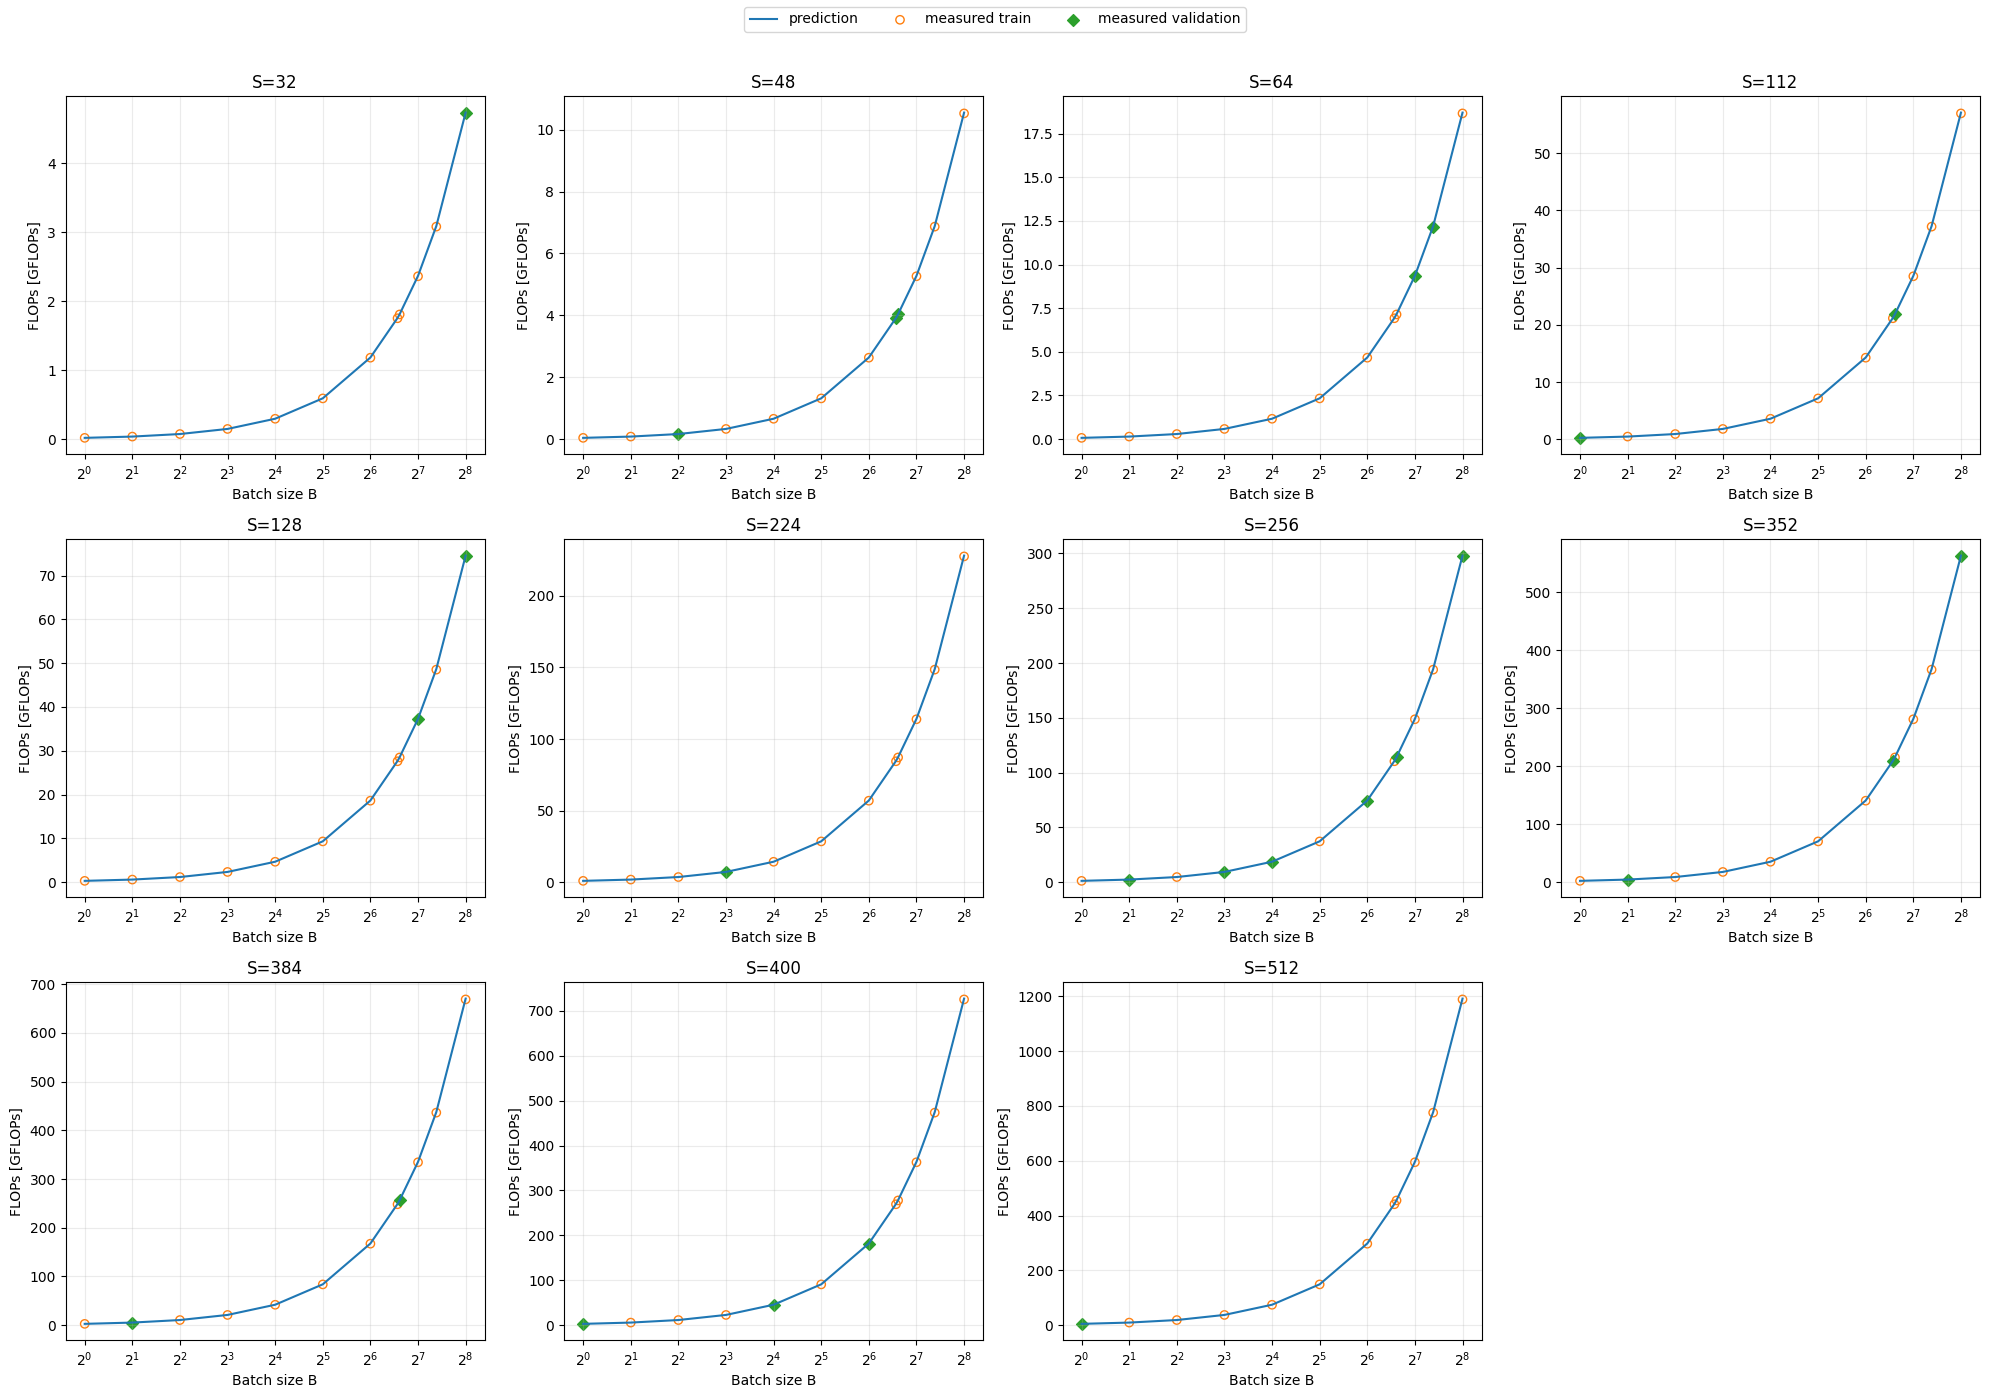

saved /content/hw1_results/figures/flops_profiler.png


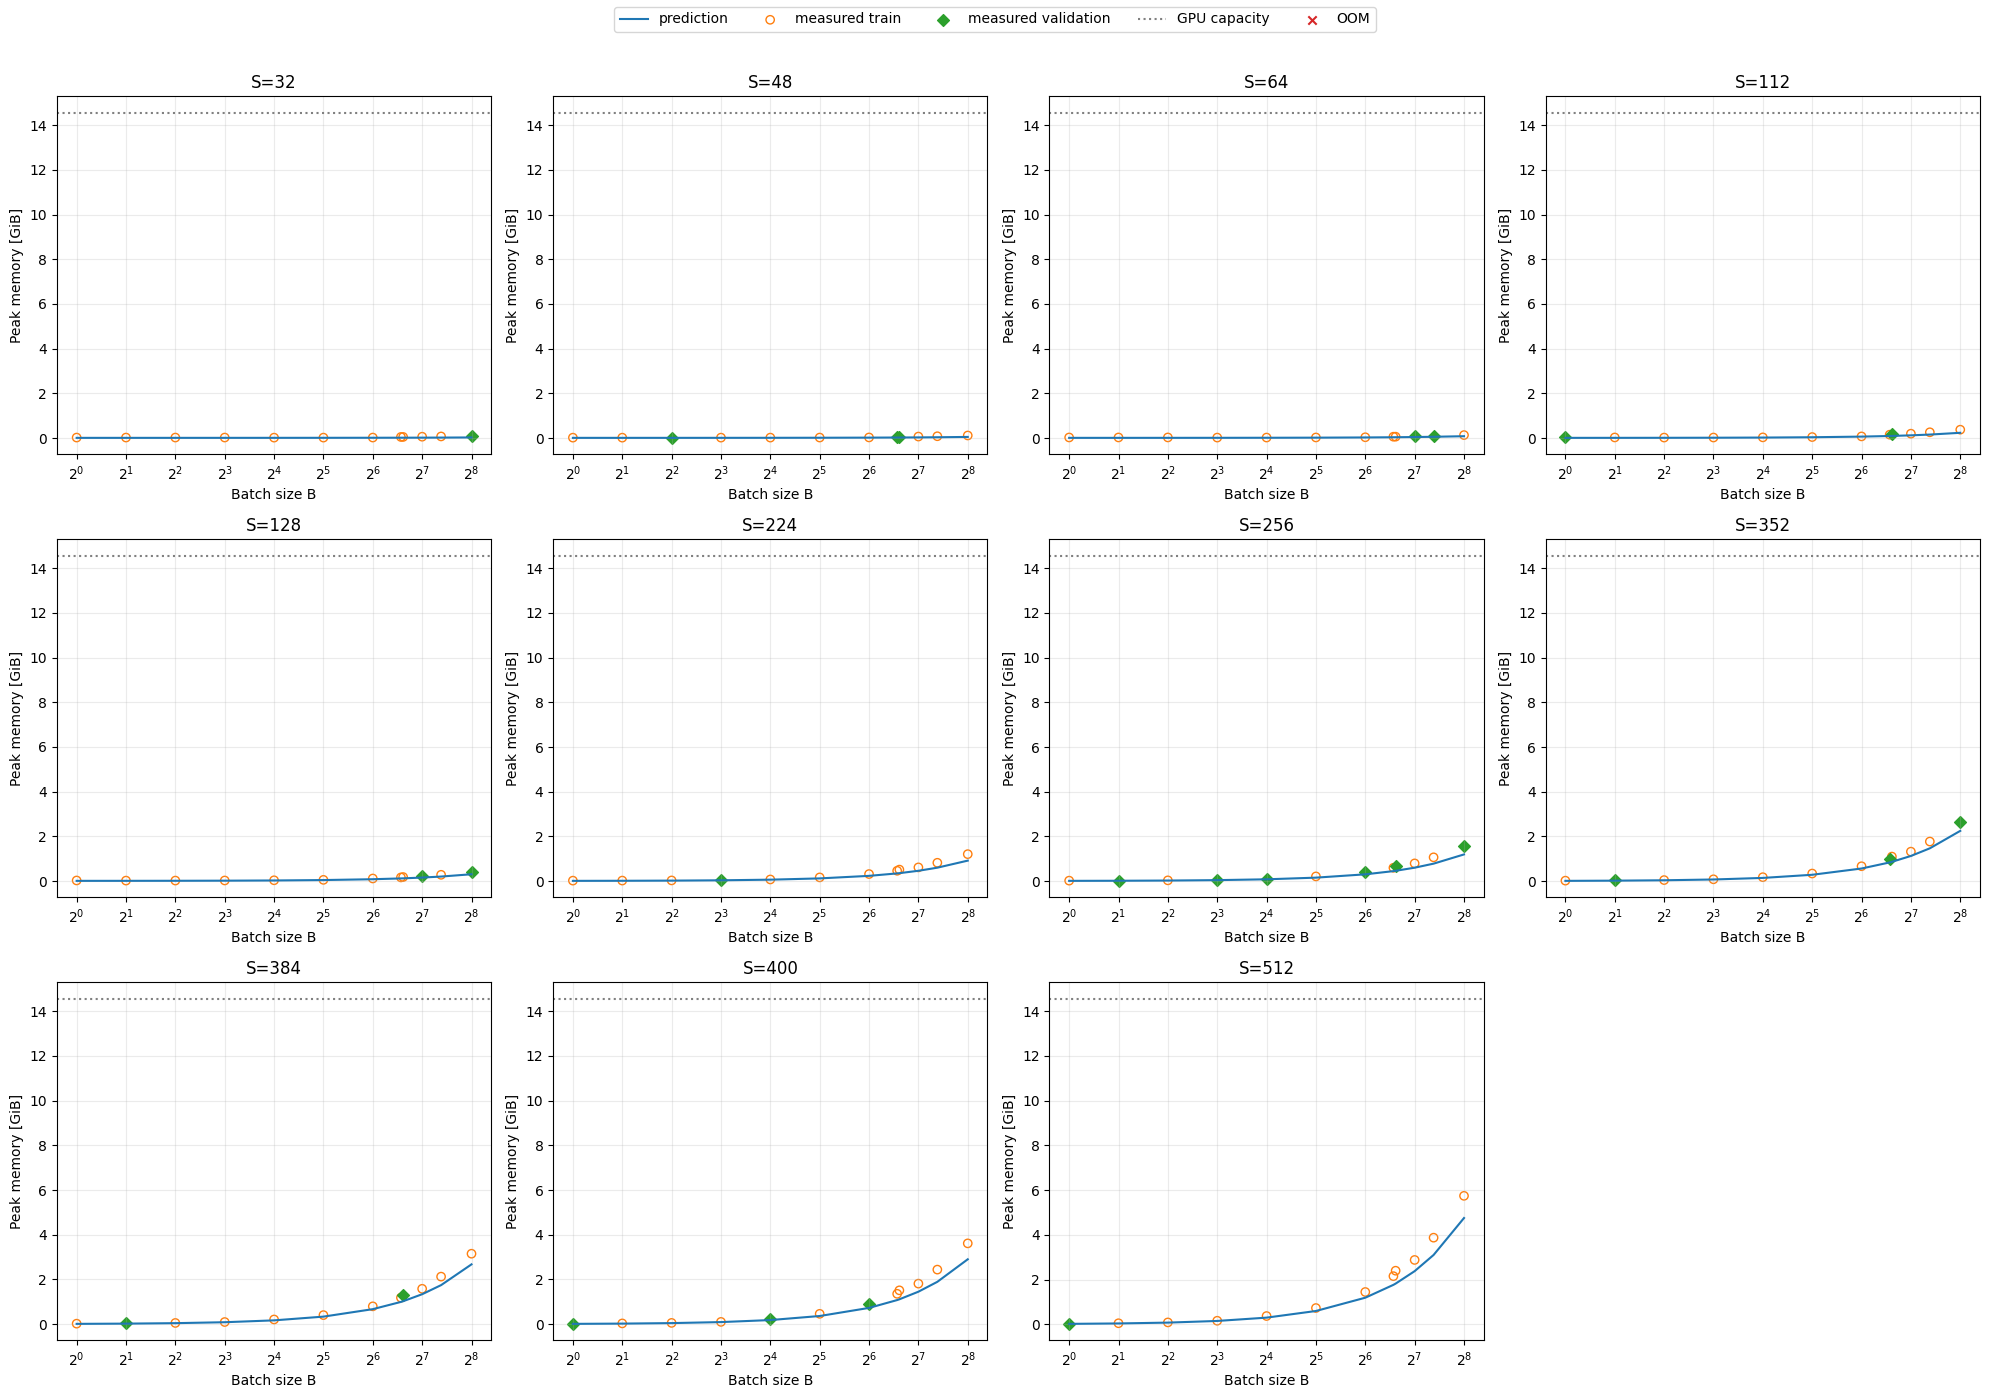

saved /content/hw1_results/figures/memory_bytes.png


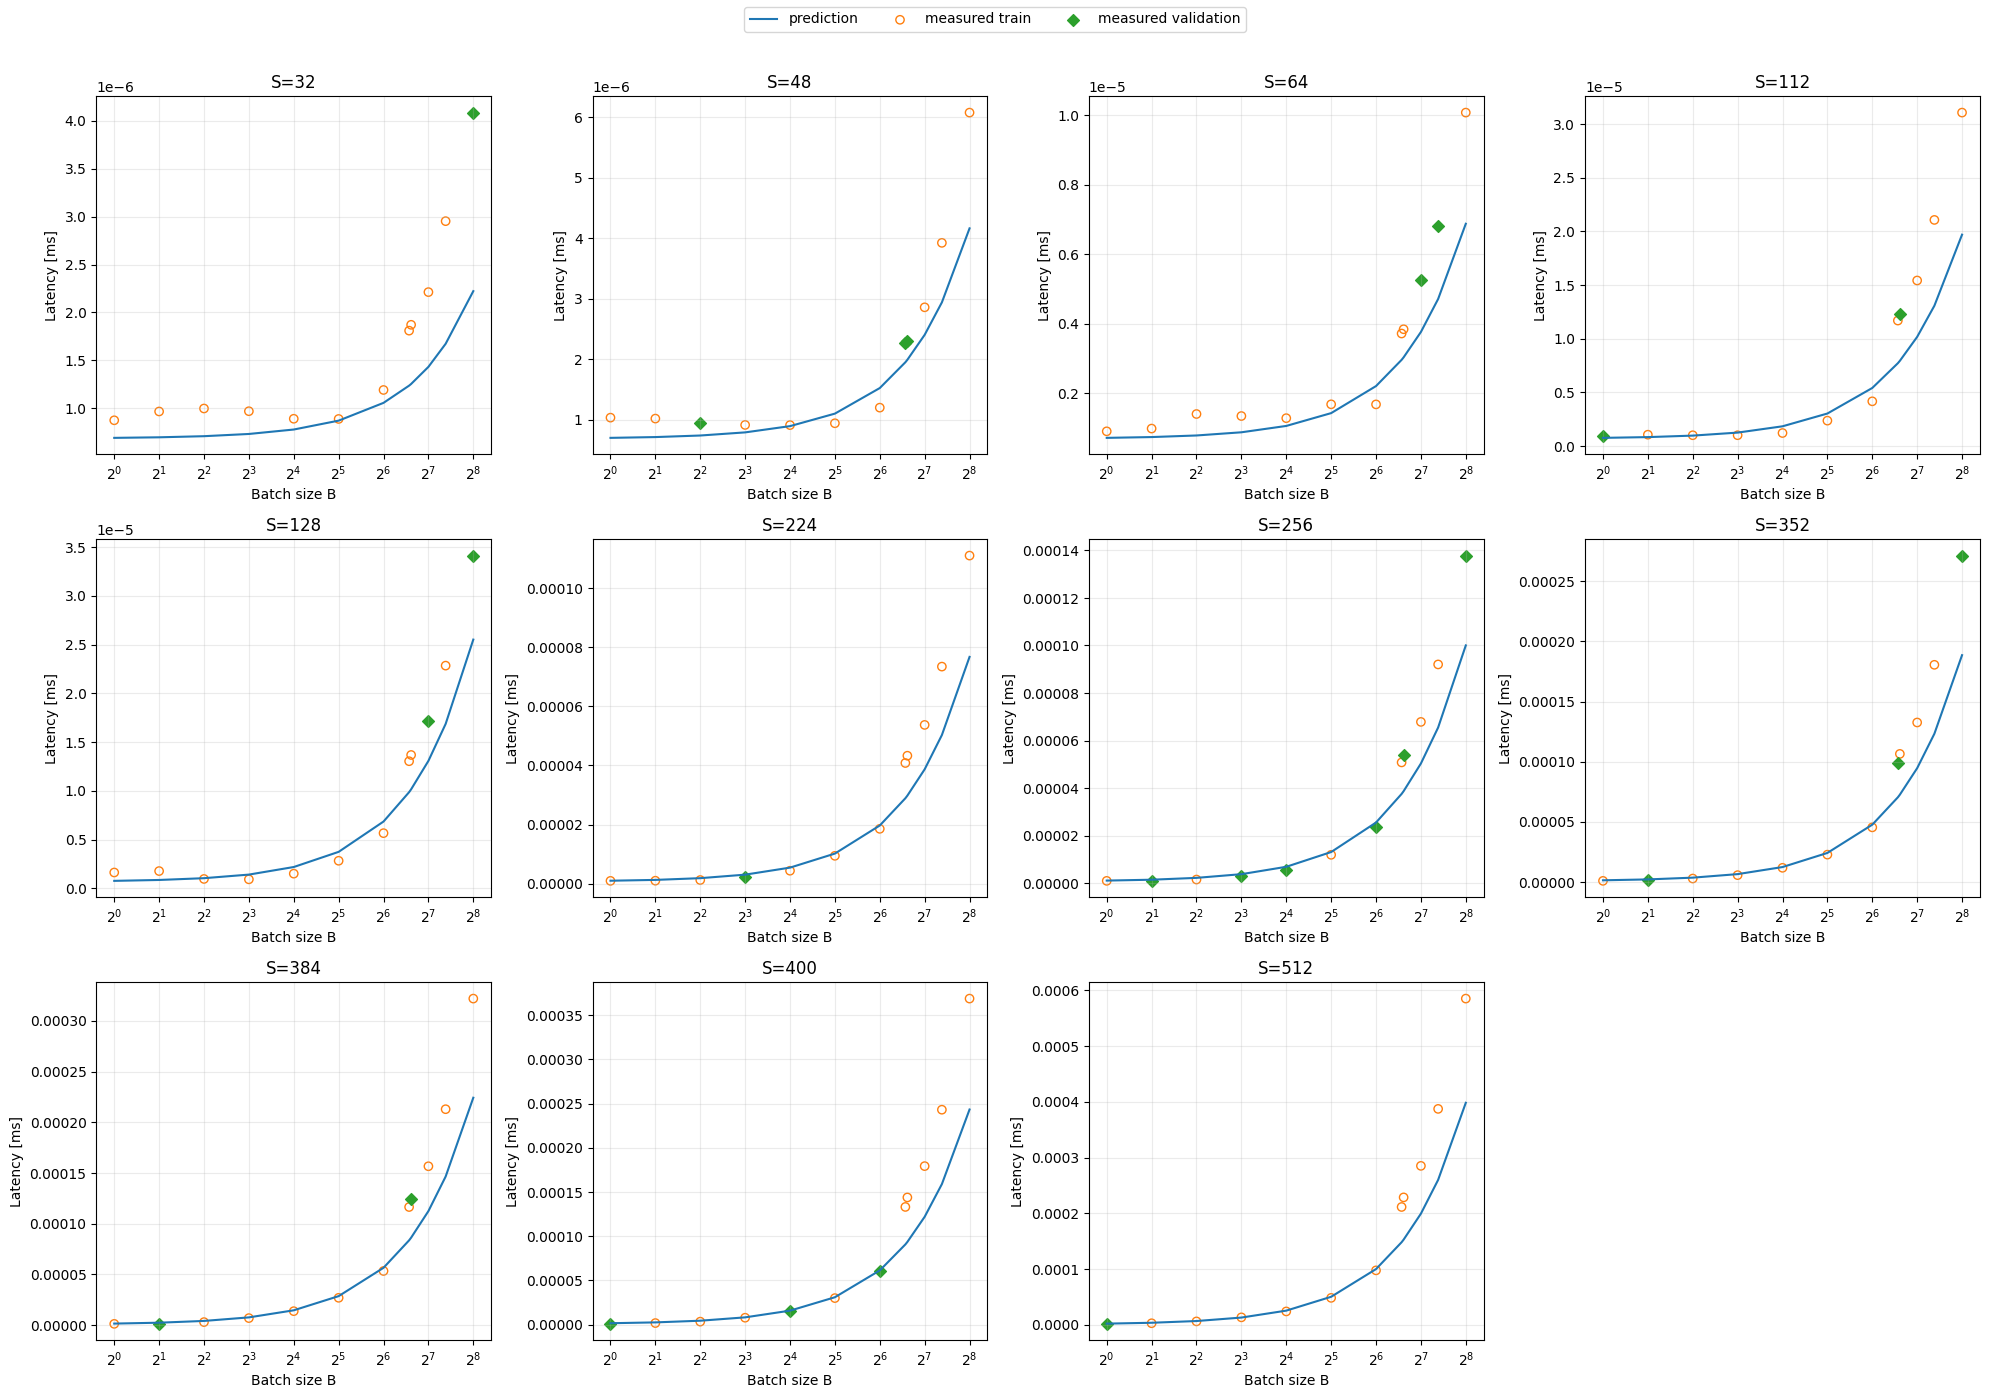

saved /content/hw1_results/figures/latency_s.png


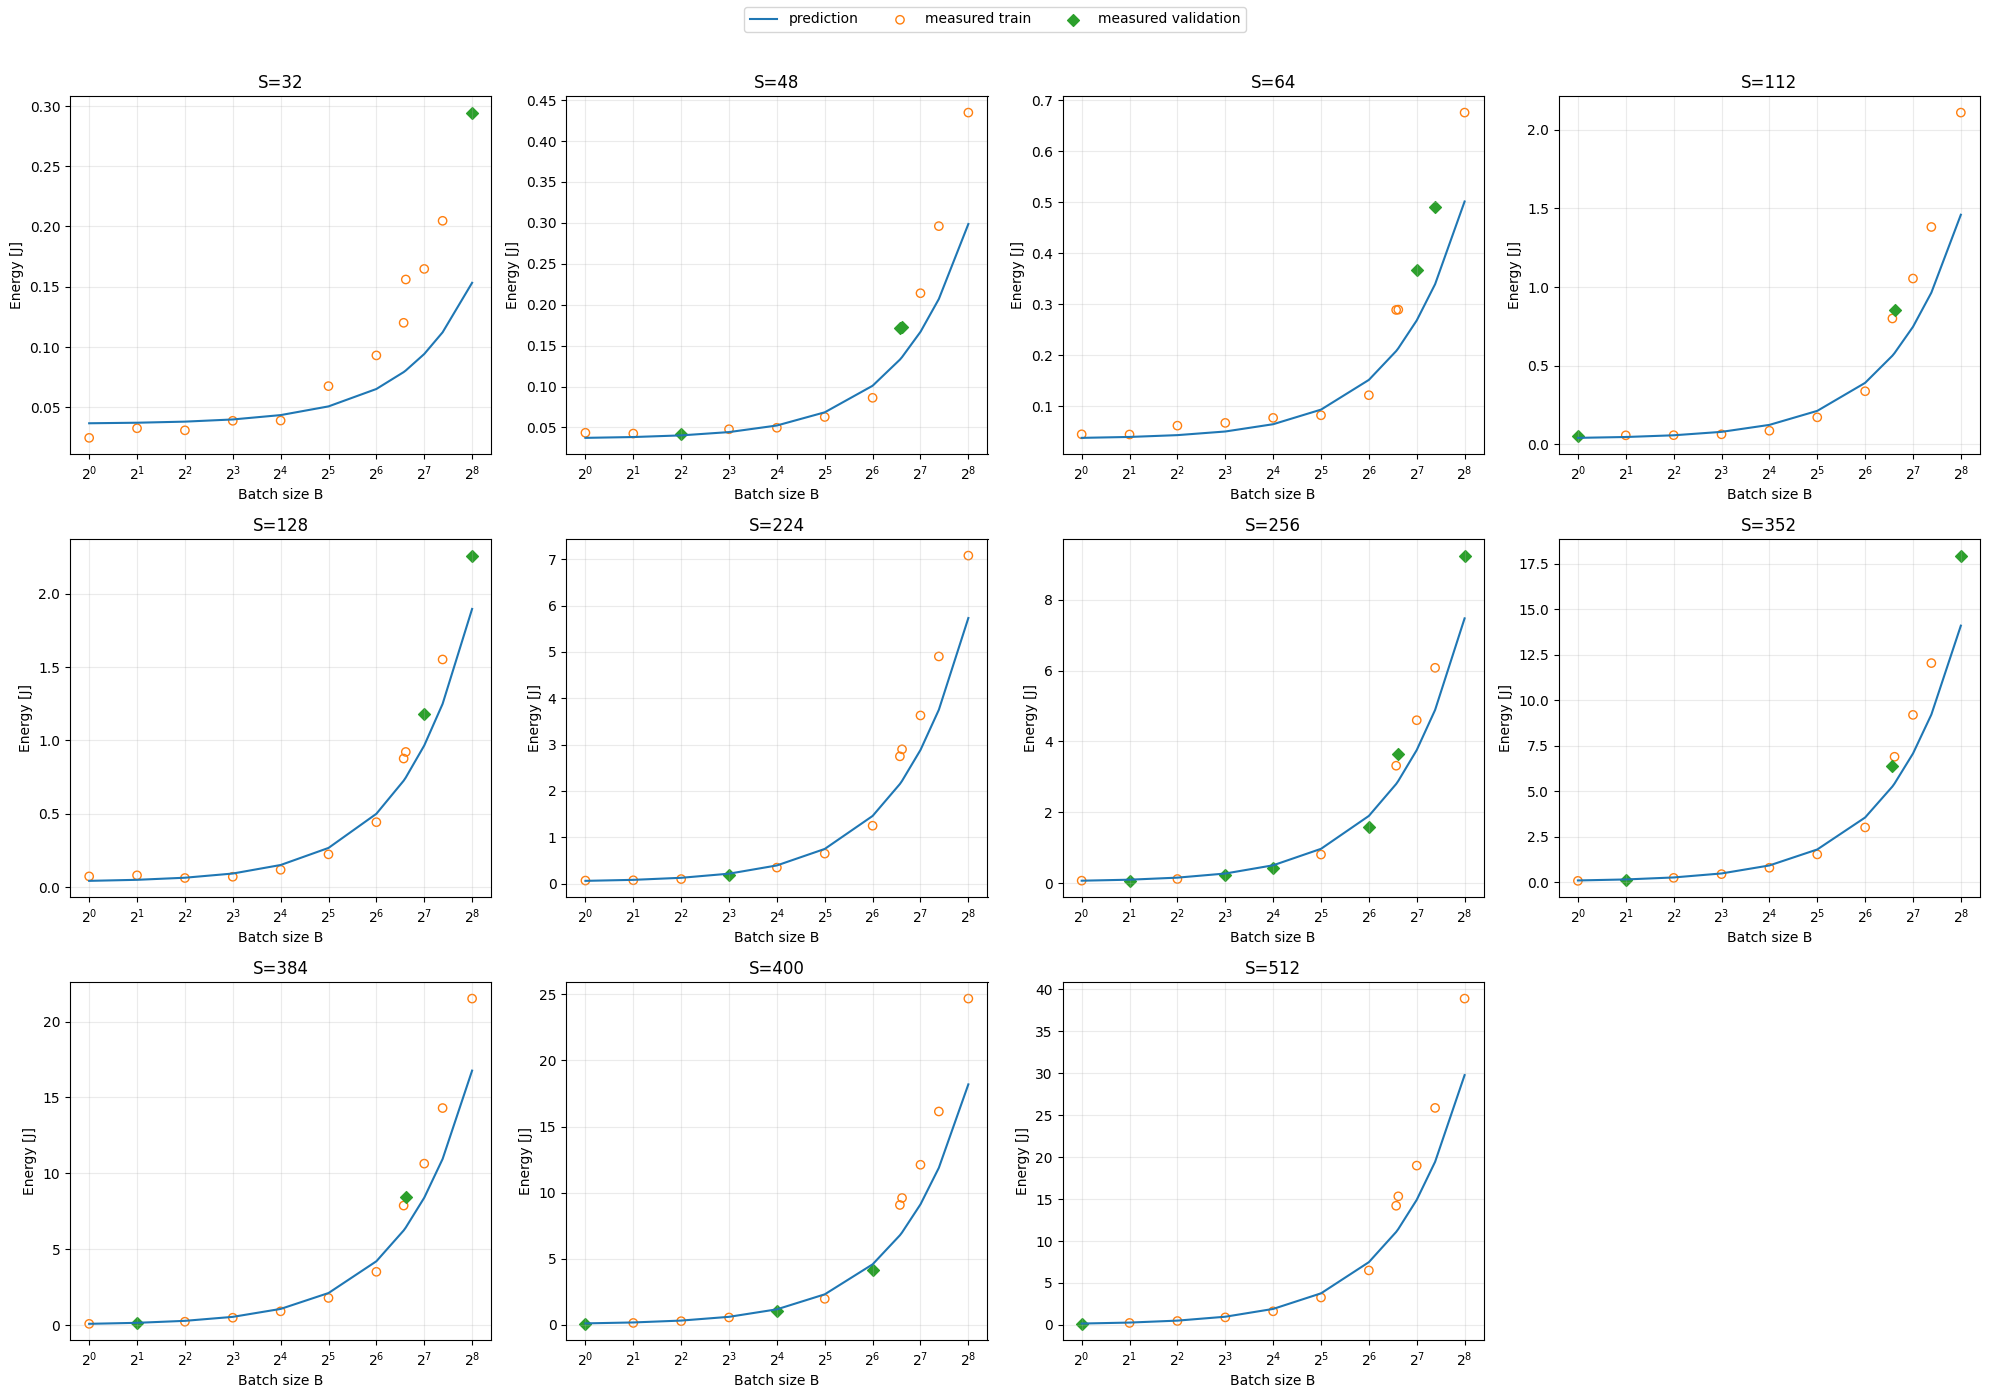

saved /content/hw1_results/figures/energy_j.png


In [11]:
df = df.copy()
df['flops_pred'] = flops(df.S.to_numpy(), df.B.to_numpy())
df['memory_pred'] = memory(df.S.to_numpy(), df.B.to_numpy())
df['latency_pred'] = latency(df.S.to_numpy(), df.B.to_numpy(), theta_t)
df['energy_pred'] = energy(df.S.to_numpy(), df.B.to_numpy(), theta_e)
metrics = [
    ('flops_profiler', 'flops_pred', 'FLOPs', 1e9, 'GFLOPs'),
    ('memory_bytes', 'memory_pred', 'Peak memory', 2**30, 'GiB'),
    ('latency_s', 'latency_pred', 'Latency', 1e3, 'ms'),
    ('energy_j', 'energy_pred', 'Energy', 1.0, 'J'),
]
for measured, predicted, title, factor, unit in metrics:
    fig, axes = plt.subplots(3, 4, figsize=(20, 14), sharey=False)
    axes = axes.ravel()
    for ax, s in zip(axes, sorted(df.S.unique())):
        sub = df[df.S == s].sort_values('B')
        good = sub[sub.status == 'ok']
        train = good[~good.is_validation]
        valid = good[good.is_validation]
        ax.plot(sub.B, sub[predicted] / factor, color='C0', label='prediction')
        ax.scatter(train.B, train[measured] / factor, facecolors='none',
                   edgecolors='C1', label='measured train')
        ax.scatter(valid.B, valid[measured] / factor, marker='D',
                   color='C2', label='measured validation')
        if measured == 'memory_bytes':
            oom = sub[sub.status == 'OOM']
            capacity = torch.cuda.get_device_properties(0).total_memory / factor
            ax.axhline(capacity, color='gray', linestyle=':', label='GPU capacity')
            ax.scatter(oom.B, [capacity] * len(oom), marker='x', color='C3', label='OOM')
        ax.set(xlabel='Batch size B', ylabel=f'{title} [{unit}]', title=f'S={s}')
        ax.set_xscale('log', base=2)
        ax.grid(alpha=0.25)
    for ax in axes[len(df.S.unique()):]:
        ax.axis('off')
    legend_items = {}
    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        legend_items.update(zip(labels, handles))
    fig.legend(legend_items.values(), legend_items.keys(), loc='upper center', ncol=5)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    output = RESULTS / 'figures' / f'{measured}.png'
    fig.savefig(output, dpi=160)
    plt.show()
    print('saved', output)

## 7. Ошибки и обсуждение

`MAPE` вычисляем отдельно для train и unseen validation. Для `OOM` сравниваем `Memory(S,B)` с физической ёмкостью GPU, но аналитическая формула намеренно не знает о cuDNN workspace. В отчёте обсуждаем: (1) где доминирует запуск kernels, (2) где растёт traffic, (3) где ограничивает compute, (4) какие предсказания не работают и почему. Отдельно укажите шум NVML и то, что profiler FLOPs — оценка Conv/Linear.

In [12]:
for split_name, mask in [('train', ~df.is_validation), ('validation', df.is_validation)]:
    part = df[mask & (df.status == 'ok')]
    print('\n', split_name, 'successful points:', len(part))
    for measured, predicted, title, _, _ in metrics:
        print(title, error_summary(part[measured], part[predicted]))
capacity = torch.cuda.get_device_properties(0).total_memory
actual_oom = df.status.eq('OOM')
predicted_oom = df.memory_pred > capacity
print('\nOOM actual:', int(actual_oom.sum()), 'predicted:', int(predicted_oom.sum()))
print('OOM confusion table:')
display(pd.crosstab(actual_oom.rename('actual'), predicted_oom.rename('predicted')))
print('Посмотрите графики и заполните one-page discussion в README своими выводами.')


 train successful points: 106
FLOPs {'n': 106, 'median_ape_percent': 0.24837163770424583, 'mean_ape_percent': 0.24799567553799107}
Peak memory {'n': 106, 'median_ape_percent': 28.428007844568093, 'mean_ape_percent': 36.809550340846386}
Latency {'n': 106, 'median_ape_percent': 28.04536146142965, 'mean_ape_percent': 25.113299707897237}
Energy {'n': 106, 'median_ape_percent': 20.661411085717916, 'mean_ape_percent': 21.09667048830951}

 validation successful points: 26
FLOPs {'n': 26, 'median_ape_percent': 0.24838277059443994, 'mean_ape_percent': 0.2481264314975837}
Peak memory {'n': 26, 'median_ape_percent': 28.90322230405938, 'mean_ape_percent': 35.754558589744256}
Latency {'n': 26, 'median_ape_percent': 27.828302255426756, 'mean_ape_percent': 28.25751111682137}
Energy {'n': 26, 'median_ape_percent': 21.00247409917064, 'mean_ape_percent': 24.092143091783218}

OOM actual: 0 predicted: 0
OOM confusion table:


predicted,False
actual,
False,132


Посмотрите графики и заполните one-page discussion в README своими выводами.


In [13]:
# Разделение на режимы по величинам членов fitted latency equation.
all_ok = df[df.status == 'ok'].copy()
compute_term = flops(all_ok.S, all_ok.B) / theta_t['compute_flops_per_s']
traffic_term = bytes_moved(all_ok.S, all_ok.B) / theta_t['memory_bytes_per_s']
launch_term = np.full(len(all_ok), theta_t['launch_seconds'])
all_ok['regime'] = np.array(['launch-bound', 'memory-bound', 'compute-bound'])[
    np.argmax(np.column_stack([launch_term, traffic_term, compute_term]), axis=1)]
print('Режимы на grid:', all_ok.regime.value_counts().to_dict())
for metric, predicted, title in [('flops_profiler','flops_pred','FLOPs'),
                                  ('memory_bytes','memory_pred','Memory'),
                                  ('latency_s','latency_pred','Latency'),
                                  ('energy_j','energy_pred','Energy')]:
    v = df[(df.status == 'ok') & df.is_validation]
    print(title, 'validation:', error_summary(v[metric], v[predicted]))

v = df[(df.status == 'ok') & df.is_validation].copy()
v['latency_ape'] = 100 * abs(v.latency_pred - v.latency_s) / v.latency_s
v['energy_ape'] = 100 * abs(v.energy_pred - v.energy_j) / v.energy_j
print('Наибольшие ошибки latency на validation:')
display(v.nlargest(5, 'latency_ape')[['S','B','latency_s','latency_pred','latency_ape']])

summary = [
    '# Результаты на T4',
    f'GPU: {GPU_NAME}; PyTorch {torch.__version__}; CUDA {torch.version.cuda}.',
    f'Grid: {len(df)} pairs; ok={int((df.status == "ok").sum())}; OOM={int((df.status == "OOM").sum())}.',
    f'Train={int((~df.is_validation).sum())}; unseen validation={int(df.is_validation.sum())}.',
    f'Fitted latency: t0={theta_t["launch_seconds"]:.6g} s, P={theta_t["compute_flops_per_s"]:.4g} FLOP/s, R={theta_t["memory_bytes_per_s"]:.4g} byte/s.',
    f'Fitted idle power: {theta_e["idle_watts"]:.3g} W.',
    f'Regimes (largest fitted term): {all_ok.regime.value_counts().to_dict()}.',
    '', '## Validation errors (median APE)',
]
for metric, predicted, title in [('flops_profiler','flops_pred','FLOPs'),
                                  ('memory_bytes','memory_pred','Memory'),
                                  ('latency_s','latency_pred','Latency'),
                                  ('energy_j','energy_pred','Energy')]:
    score = error_summary(v[metric], v[predicted])
    summary.append(f'- {title}: {score["median_ape_percent"]:.2f}% (n={score["n"]})')
summary += [
    '', '## Обсуждение',
    'FLOPs profiler учитывает Conv/Linear, а аналитическая формула дополнительно BN/GAP; это ожидаемое систематическое расхождение.',
    'Peak memory зависит также от cuDNN workspace и allocator; формула учитывает только живые FP32 тензоры и weights.',
    'Roofline-style latency не описывает kernel selection, launch overhead отдельных operators и изменение clocks; посмотрите пять худших validation points выше.',
    'NVML energy усреднена за серию forwards; частота sensor и внешняя нагрузка создают шум.',
    'Если memory-bound points отсутствуют, fitted R плохо идентифицируется — не трактуйте его как физическую bandwidth GPU.',
    f'Actual OOM={int(actual_oom.sum())}, predicted OOM={int(predicted_oom.sum())}; сравните ошибочные случаи с workspace и доступной VRAM.',
]
summary_path = RESULTS / 'results_summary.md'
summary_path.write_text('\n'.join(summary) + '\n', encoding='utf-8')
print('Сводка сохранена:', summary_path)


Режимы на grid: {'compute-bound': 101, 'launch-bound': 30, 'memory-bound': 1}
FLOPs validation: {'n': 26, 'median_ape_percent': 0.24838277059443994, 'mean_ape_percent': 0.2481264314975837}
Memory validation: {'n': 26, 'median_ape_percent': 28.90322230405938, 'mean_ape_percent': 35.754558589744256}
Latency validation: {'n': 26, 'median_ape_percent': 27.828302255426756, 'mean_ape_percent': 28.25751111682137}
Energy validation: {'n': 26, 'median_ape_percent': 21.00247409917064, 'mean_ape_percent': 24.092143091783218}
Наибольшие ошибки latency на validation:


,S,B,latency_s,latency_pred,latency_ape
108,400,1,0.000875,0.001591,81.782668
97,384,2,0.001592,0.002390,50.146124
11,32,256,0.004084,0.002222,45.587539
73,256,2,0.000996,0.001419,42.546358
85,352,2,0.001491,0.002111,41.546843


Сводка сохранена: /content/hw1_results/results_summary.md


## 8. Что приложить к сдаче

Из репозитория: `models.py`, `equations.py`, `measure.py` (и notebook), `calibrate.py`, `results/measurements.csv`, `results/theta.json`, `results/figures/*.png`, `README.md`. Кроме этого нужен **собственноручно написанный** `hw1_handwritten.pdf` с выводом четырёх формул и предположений — этот файл автоматически не создаётся.

В Colab `results` остаются в удалённой файловой системе. После Run All скачайте архив из последней ячейки и добавьте файлы в `hw1/results/` своего репозитория.

In [14]:
import shutil
archive = shutil.make_archive(str(RESULTS.parent / 'hw1_results'), 'zip', root_dir=RESULTS)
print('Архив результатов для скачивания из панели Files в Colab:', archive)

Архив результатов для скачивания из панели Files в Colab: /content/hw1_results.zip
